# Notebook 5: Data Generation & Descriptive Analysis (MML Pipeline)

This notebook walks through the **data simulation** and **descriptive analysis** from the German PISA Mathematical Literacy example (Wilson, De Boeck & Carstensen, 2008).

We run scripts `01_generate_data.py` and `02_descriptive_analysis.py` step by step.

---

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

np.random.seed(42)

## 1. Define the Experimental Design (18 Items)

In [2]:
# Define the factorial design: 3 topic areas × 3 modeling types × 2 items each = 18 items
topic_areas = ["Arithmetic", "Geometry", "Algebra"]
modeling_types = ["TechnicalProcessing", "NumericalModeling", "AbstractModeling"]

items = []
item_id = 0
for ta in topic_areas:
    for mt in modeling_types:
        for rep in range(2):  # 2 items per cell
            items.append({
                "item_id": item_id,
                "item_name": f"{ta[:3]}_{mt[:4]}_{rep+1}",
                "topic_area": ta,
                "modeling_type": mt,
            })
            item_id += 1

items_df = pd.DataFrame(items)
print(f"Created {len(items_df)} items in a {len(topic_areas)} × {len(modeling_types)} × 2 factorial design")
print(items_df)

Created 18 items in a 3 × 3 × 2 factorial design
    item_id   item_name  topic_area        modeling_type
0         0  Ari_Tech_1  Arithmetic  TechnicalProcessing
1         1  Ari_Tech_2  Arithmetic  TechnicalProcessing
2         2  Ari_Nume_1  Arithmetic    NumericalModeling
3         3  Ari_Nume_2  Arithmetic    NumericalModeling
4         4  Ari_Abst_1  Arithmetic     AbstractModeling
5         5  Ari_Abst_2  Arithmetic     AbstractModeling
6         6  Geo_Tech_1    Geometry  TechnicalProcessing
7         7  Geo_Tech_2    Geometry  TechnicalProcessing
8         8  Geo_Nume_1    Geometry    NumericalModeling
9         9  Geo_Nume_2    Geometry    NumericalModeling
10       10  Geo_Abst_1    Geometry     AbstractModeling
11       11  Geo_Abst_2    Geometry     AbstractModeling
12       12  Alg_Tech_1     Algebra  TechnicalProcessing
13       13  Alg_Tech_2     Algebra  TechnicalProcessing
14       14  Alg_Nume_1     Algebra    NumericalModeling
15       15  Alg_Nume_2     Algebra    

## 2. True Item Difficulty Parameters (from Table 6)

In [3]:
# These are the "true" β values for each topic_area × modeling_type cell
# Inspired by Table 6 from the Wilson, De Boeck & Carstensen (2008) paper
true_item_effects = {
    ("Arithmetic", "TechnicalProcessing"): -1.16,
    ("Arithmetic", "NumericalModeling"):    0.24,
    ("Arithmetic", "AbstractModeling"):    -0.51,
    ("Algebra",    "TechnicalProcessing"): -0.13,
    ("Algebra",    "NumericalModeling"):    0.69,
    ("Algebra",    "AbstractModeling"):     0.97,
    ("Geometry",   "TechnicalProcessing"): -0.20,
    ("Geometry",   "NumericalModeling"):    0.07,
    ("Geometry",   "AbstractModeling"):     0.58,
}

# Add small noise per item within each cell (two items per cell)
items_df["beta_cell"] = items_df.apply(
    lambda r: true_item_effects[(r["topic_area"], r["modeling_type"])], axis=1
)
noise = np.random.normal(0, 0.08, len(items_df))
items_df["beta_true"] = items_df["beta_cell"] + noise

print("Item Difficulty Parameters (β values):")
print(items_df[["item_name", "topic_area", "modeling_type", "beta_cell", "beta_true"]])
print(f"\nDifficulty range: [{items_df['beta_true'].min():.3f}, {items_df['beta_true'].max():.3f}]")

Item Difficulty Parameters (β values):
     item_name  topic_area        modeling_type  beta_cell  beta_true
0   Ari_Tech_1  Arithmetic  TechnicalProcessing      -1.16  -1.120263
1   Ari_Tech_2  Arithmetic  TechnicalProcessing      -1.16  -1.171061
2   Ari_Nume_1  Arithmetic    NumericalModeling       0.24   0.291815
3   Ari_Nume_2  Arithmetic    NumericalModeling       0.24   0.361842
4   Ari_Abst_1  Arithmetic     AbstractModeling      -0.51  -0.528732
5   Ari_Abst_2  Arithmetic     AbstractModeling      -0.51  -0.528731
6   Geo_Tech_1    Geometry  TechnicalProcessing      -0.20  -0.073663
7   Geo_Tech_2    Geometry  TechnicalProcessing      -0.20  -0.138605
8   Geo_Nume_1    Geometry    NumericalModeling       0.07   0.032442
9   Geo_Nume_2    Geometry    NumericalModeling       0.07   0.113405
10  Geo_Abst_1    Geometry     AbstractModeling       0.58   0.542927
11  Geo_Abst_2    Geometry     AbstractModeling       0.58   0.542742
12  Alg_Tech_1     Algebra  TechnicalProcessing    

## 3. Generate Person Properties (881 Students)

In [4]:
# Sample size
N = 881

# Gender: 0 = female, 1 = male (roughly 50/50)
gender = np.random.binomial(1, 0.50, N)

# Program: 1=Hauptschule(22%), 2=Integrated(10%), 3=Realschule(32%), 4=Gymnasium(36%)
program = np.random.choice([1, 2, 3, 4], size=N, p=[0.22, 0.10, 0.32, 0.36])

# HiSES: continuous, standardized
hises = np.random.normal(0, 1, N)

# Summary statistics
print(f"Sample size: {N} students")
print(f"\nGender distribution:")
print(f"  Female (0): {(gender == 0).sum()} ({(gender == 0).sum()/N*100:.1f}%)")
print(f"  Male (1):   {(gender == 1).sum()} ({(gender == 1).sum()/N*100:.1f}%)")

prog_names = {1: "Hauptschule", 2: "Integrated", 3: "Realschule", 4: "Gymnasium"}
print(f"\nProgram distribution:")
for prog in [1, 2, 3, 4]:
    count = (program == prog).sum()
    print(f"  {prog} ({prog_names[prog]:12s}): {count:3d} ({count/N*100:.1f}%)")

print(f"\nHiSES (standardized) summary:")
print(f"  Mean: {hises.mean():.3f}, SD: {hises.std():.3f}")

Sample size: 881 students

Gender distribution:
  Female (0): 440 (49.9%)
  Male (1):   441 (50.1%)

Program distribution:
  1 (Hauptschule ): 192 (21.8%)
  2 (Integrated  ):  87 (9.9%)
  3 (Realschule  ): 274 (31.1%)
  4 (Gymnasium   ): 328 (37.2%)

HiSES (standardized) summary:
  Mean: 0.039, SD: 0.988


## 4. True Person Ability (Latent Regression Model)

In [5]:
# True effects of person properties (inspired by paper results)
true_program_effects = {1: -0.49, 2: 0.00, 3: 0.80, 4: 1.89}
true_gender_x_program = {1: -0.11, 2: 0.00, 3: -0.22, 4: -0.30}
true_ses_effect = 0.20  # scaled for standardized SES

# Compute the fixed part of person ability
theta_fixed = np.array([true_program_effects[p] for p in program])
theta_gender_prog = np.array([
    true_gender_x_program[p] * (1 - g)  # effect for females (gender=0)
    for p, g in zip(program, gender)
])
theta_ses = true_ses_effect * hises

# Residual random person effect ~ N(0, sigma_e^2)
sigma_e = np.sqrt(0.67)  # residual variance after accounting for predictors
theta_residual = np.random.normal(0, sigma_e, N)

# Combine to get true person ability
theta_p = theta_fixed + theta_gender_prog + theta_ses + theta_residual

print("True Person Ability (θ) Summary:")
print(f"  Mean:        {theta_p.mean():.4f}")
print(f"  SD:          {theta_p.std():.4f}")
print(f"  Min:         {theta_p.min():.4f}")
print(f"  Max:         {theta_p.max():.4f}")
print(f"  Variance:    {np.var(theta_p):.4f}")
print(f"\nVariance decomposition:")
print(f"  Total variance:         {np.var(theta_p):.4f}")
print(f"  Residual variance:      {sigma_e**2:.4f}")

True Person Ability (θ) Summary:
  Mean:        0.7529
  SD:          1.1989
  Min:         -3.5361
  Max:         4.2266
  Variance:    1.4374

Variance decomposition:
  Total variance:         1.4374
  Residual variance:      0.6700


## 5. Simulate Binary Responses

In [6]:
# Extract item difficulty parameters
beta = items_df["beta_true"].values  # shape (18,)

# η_pi = θ_p - β_i  (logit model)
# prob_pi = 1 / (1 + exp(-η_pi))
eta = theta_p[:, None] - beta[None, :]  # shape (N, 18)
prob = 1 / (1 + np.exp(-eta))           # logistic function
responses = (np.random.uniform(size=(N, 18)) < prob).astype(int)

print(f"Response matrix shape: {responses.shape}")
print(f"  Rows (persons): {responses.shape[0]}")
print(f"  Columns (items): {responses.shape[1]}")
print(f"\nResponse statistics:")
print(f"  Overall mean response rate: {responses.mean():.4f}")
print(f"  Item-wise response rates (first 6):")
for i in range(6):
    print(f"    Item {i}: {responses[:, i].mean():.3f}")

Response matrix shape: (881, 18)
  Rows (persons): 881
  Columns (items): 18

Response statistics:
  Overall mean response rate: 0.6273
  Item-wise response rates (first 6):
    Item 0: 0.806
    Item 1: 0.817
    Item 2: 0.594
    Item 3: 0.586
    Item 4: 0.736
    Item 5: 0.725


## 6. Build and Save Data Files

In [7]:
# Person-level data
persons_df = pd.DataFrame({
    "person_id": range(N),
    "gender": gender,
    "program": program,
    "hises": np.round(hises, 4),
    "theta_true": np.round(theta_p, 4),
})

# Response matrix with column names = item names
resp_cols = items_df["item_name"].tolist()
resp_df = pd.DataFrame(responses, columns=resp_cols)
resp_df.insert(0, "person_id", range(N))

# Combined long-format data (useful for GLMM fitting)
long_rows = []
for p in range(N):
    for i in range(18):
        long_rows.append({
            "person_id": p,
            "item_id": i,
            "response": responses[p, i],
        })
long_df = pd.DataFrame(long_rows)

# Save files to working directory
out_dir = os.getcwd()

items_df.to_csv(os.path.join(out_dir, "data_items.csv"), index=False)
persons_df.to_csv(os.path.join(out_dir, "data_persons.csv"), index=False)
resp_df.to_csv(os.path.join(out_dir, "data_responses.csv"), index=False)
long_df.to_csv(os.path.join(out_dir, "data_long.csv"), index=False)

print("=" * 60)
print("DATA GENERATION COMPLETE")
print("=" * 60)
print(f"  Students:  {N}")
print(f"  Items:     {len(items_df)}")
print(f"  Responses: {responses.shape[0]} × {responses.shape[1]}")
print(f"\nFiles saved:")
print(f"  data_items.csv     — item design and true parameters")
print(f"  data_persons.csv   — person properties and true θ")
print(f"  data_responses.csv — binary response matrix (wide)")
print(f"  data_long.csv      — long-format (person × item × response)")
print(f"\nTrue parameter summary:")
print(f"  Person variance (total):    {np.var(theta_p):.3f}")
print(f"  Person variance (residual): {sigma_e**2:.3f}")
print(f"  Item difficulty range:      [{beta.min():.3f}, {beta.max():.3f}]")
print(f"  Mean response rate:         {responses.mean():.3f}")

DATA GENERATION COMPLETE
  Students:  881
  Items:     18
  Responses: 881 × 18

Files saved:
  data_items.csv     — item design and true parameters
  data_persons.csv   — person properties and true θ
  data_responses.csv — binary response matrix (wide)
  data_long.csv      — long-format (person × item × response)

True parameter summary:
  Person variance (total):    1.437
  Person variance (residual): 0.670
  Item difficulty range:      [-1.171, 0.995]
  Mean response rate:         0.627


## 7. Item-Level Descriptive Statistics

In [8]:
# Load data (or use already-loaded data from above)
resp_matrix = resp_df.drop(columns=["person_id"]).values
item_names = resp_df.columns[1:].tolist()

# Compute item-level statistics
item_means = resp_matrix.mean(axis=0)
items_df["p_value"] = item_means

print("=" * 60)
print("ITEM-LEVEL STATISTICS")
print("=" * 60)
print(items_df[["item_name", "topic_area", "modeling_type", "p_value", "beta_true"]].to_string(index=False))

# Mean by topic area
print("\nMean scores by Topic Area:")
for ta in ["Arithmetic", "Geometry", "Algebra"]:
    mask = items_df["topic_area"] == ta
    print(f"  {ta:12s}: {item_means[mask].mean():.3f}")

# Mean by modeling type
print("\nMean scores by Modeling Type:")
for mt in ["TechnicalProcessing", "NumericalModeling", "AbstractModeling"]:
    mask = items_df["modeling_type"] == mt
    print(f"  {mt:22s}: {item_means[mask].mean():.3f}")

# Cross-tabulation: topic_area × modeling_type
print("\nMean scores by Topic Area × Modeling Type:")
cross = items_df.groupby(["topic_area", "modeling_type"])["p_value"].mean().unstack()
cross = cross.reindex(index=["Arithmetic", "Geometry", "Algebra"],
                       columns=["TechnicalProcessing", "NumericalModeling", "AbstractModeling"])
print(cross.round(3).to_string())

ITEM-LEVEL STATISTICS
 item_name topic_area       modeling_type  p_value  beta_true
Ari_Tech_1 Arithmetic TechnicalProcessing 0.805902  -1.120263
Ari_Tech_2 Arithmetic TechnicalProcessing 0.817253  -1.171061
Ari_Nume_1 Arithmetic   NumericalModeling 0.593644   0.291815
Ari_Nume_2 Arithmetic   NumericalModeling 0.585698   0.361842
Ari_Abst_1 Arithmetic    AbstractModeling 0.735528  -0.528732
Ari_Abst_2 Arithmetic    AbstractModeling 0.725312  -0.528731
Geo_Tech_1   Geometry TechnicalProcessing 0.641317  -0.073663
Geo_Tech_2   Geometry TechnicalProcessing 0.664018  -0.138605
Geo_Nume_1   Geometry   NumericalModeling 0.633371   0.032442
Geo_Nume_2   Geometry   NumericalModeling 0.628831   0.113405
Geo_Abst_1   Geometry    AbstractModeling 0.552781   0.542927
Geo_Abst_2   Geometry    AbstractModeling 0.549376   0.542742
Alg_Tech_1    Algebra TechnicalProcessing 0.666288  -0.110643
Alg_Tech_2    Algebra TechnicalProcessing 0.699205  -0.283062
Alg_Nume_1    Algebra   NumericalModeling 0.5595

## 8. Person-Level Descriptive Statistics

In [9]:
# Compute sum scores for each person
sum_scores = resp_matrix.sum(axis=1)
persons_df["sum_score"] = sum_scores

print("=" * 60)
print("PERSON-LEVEL STATISTICS")
print("=" * 60)
print(f"  Mean sum score:   {sum_scores.mean():.2f}")
print(f"  SD sum score:     {sum_scores.std():.2f}")
print(f"  Min:              {sum_scores.min()}")
print(f"  Max:              {sum_scores.max()}")

print("\nMean sum score by Program:")
prog_names = {1: "Hauptschule", 2: "Integrated", 3: "Realschule", 4: "Gymnasium"}
for prog in [1, 2, 3, 4]:
    mask = persons_df["program"] == prog
    print(f"  {prog} ({prog_names[prog]:12s}): {sum_scores[mask].mean():.2f}  (n={mask.sum()})")

print("\nMean sum score by Gender:")
for g in [0, 1]:
    mask = persons_df["gender"] == g
    label = "Female" if g == 0 else "Male"
    print(f"  {label:8s}: {sum_scores[mask].mean():.2f}  (n={mask.sum()})")

print("\nMean sum score by Gender × Program:")
for prog in [1, 2, 3, 4]:
    for g in [0, 1]:
        mask = (persons_df["program"] == prog) & (persons_df["gender"] == g)
        label = f"  Prog {prog}, {'F' if g == 0 else 'M'}"
        print(f"{label}: {sum_scores[mask].mean():.2f}  (n={mask.sum()})")

PERSON-LEVEL STATISTICS
  Mean sum score:   11.29
  SD sum score:     4.35
  Min:              0
  Max:              18

Mean sum score by Program:
  1 (Hauptschule ): 6.81  (n=192)
  2 (Integrated  ): 9.11  (n=87)
  3 (Realschule  ): 11.42  (n=274)
  4 (Gymnasium   ): 14.39  (n=328)

Mean sum score by Gender:
  Female  : 11.13  (n=440)
  Male    : 11.45  (n=441)

Mean sum score by Gender × Program:
  Prog 1, F: 6.69  (n=90)
  Prog 1, M: 6.91  (n=102)
  Prog 2, F: 8.06  (n=35)
  Prog 2, M: 9.83  (n=52)
  Prog 3, F: 11.13  (n=147)
  Prog 3, M: 11.75  (n=127)
  Prog 4, F: 14.15  (n=168)
  Prog 4, M: 14.64  (n=160)


## 9. Descriptive Visualizations

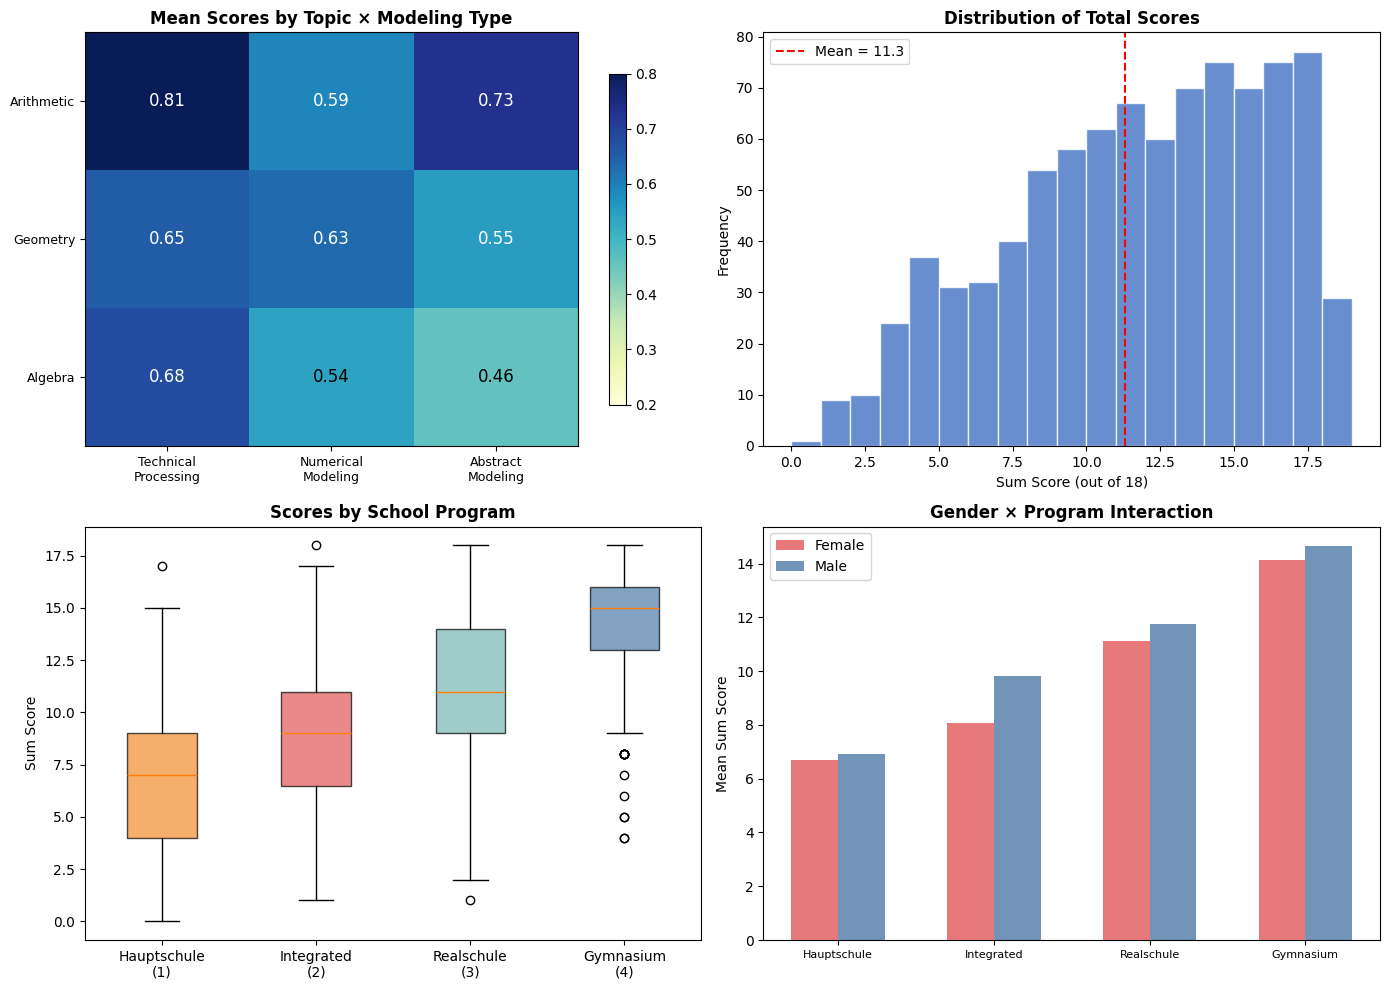


Figure saved: fig_descriptive.png


In [10]:
# Create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Heatmap of mean scores
ax = axes[0, 0]
heatdata = cross.values
im = ax.imshow(heatdata, cmap="YlGnBu", aspect="auto", vmin=0.2, vmax=0.8)
ax.set_xticks(range(3))
ax.set_xticklabels(["Technical\nProcessing", "Numerical\nModeling", "Abstract\nModeling"], fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels(["Arithmetic", "Geometry", "Algebra"], fontsize=9)
ax.set_title("Mean Scores by Topic × Modeling Type", fontweight="bold")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{heatdata[i, j]:.2f}", ha="center", va="center",
                color="white" if heatdata[i, j] > 0.55 else "black", fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) Distribution of sum scores
ax = axes[0, 1]
ax.hist(sum_scores, bins=range(0, 20), edgecolor="white", color="#4472C4", alpha=0.8)
ax.set_xlabel("Sum Score (out of 18)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Total Scores", fontweight="bold")
ax.axvline(sum_scores.mean(), color="red", linestyle="--", label=f"Mean = {sum_scores.mean():.1f}")
ax.legend()

# (c) Box plots by program
ax = axes[1, 0]
prog_data = [sum_scores[persons_df["program"] == p] for p in [1, 2, 3, 4]]
bp = ax.boxplot(prog_data, tick_labels=["Hauptschule\n(1)", "Integrated\n(2)",
                                     "Realschule\n(3)", "Gymnasium\n(4)"],
                patch_artist=True)
colors = ["#F28E2B", "#E15759", "#76B7B2", "#4E79A7"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Sum Score")
ax.set_title("Scores by School Program", fontweight="bold")

# (d) Mean scores by gender × program
ax = axes[1, 1]
progs = [1, 2, 3, 4]
female_means = [sum_scores[(persons_df["program"] == p) & (persons_df["gender"] == 0)].mean() for p in progs]
male_means = [sum_scores[(persons_df["program"] == p) & (persons_df["gender"] == 1)].mean() for p in progs]
x = np.arange(4)
ax.bar(x - 0.15, female_means, 0.3, label="Female", color="#E15759", alpha=0.8)
ax.bar(x + 0.15, male_means, 0.3, label="Male", color="#4E79A7", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Hauptschule", "Integrated", "Realschule", "Gymnasium"], fontsize=8)
ax.set_ylabel("Mean Sum Score")
ax.set_title("Gender × Program Interaction", fontweight="bold")
ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(os.getcwd(), "fig_descriptive.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFigure saved: fig_descriptive.png")

## 10. Validation Check

In [11]:
# Correlation between sum score and true theta
r = np.corrcoef(sum_scores, persons_df["theta_true"])[0, 1]

print(f"\nCorrelation between sum score and true θ: r = {r:.3f}")
print("(This shows the sum score is a reasonable but imperfect measure of ability)")
print(f"\nThis correlation suggests that the observed sum scores capture about {r**2*100:.1f}% of the variance in true ability.")


Correlation between sum score and true θ: r = 0.901
(This shows the sum score is a reasonable but imperfect measure of ability)

This correlation suggests that the observed sum scores capture about 81.2% of the variance in true ability.
